# NiVScan Model A: CharCNN-BiLSTM-CRF
## Baseline Neural NER (No Pretrained Knowledge)

**Author:** Kelompok 11 - NiVScan Project
**Date:** 2026

---

### Model A Specification:
| Aspek | Detail |
|-------|--------|
| **Arsitektur** | CharCNN + BiLSTM + CRF |
| **Pretrained** | Random init (tidak pretrained) |
| **Tokenizer** | Whitespace + char-level (independen dari B/C/D) |
| **Input** | silver_train.csv + silver_val.csv |
| **Label** | B-DISEASE, I-DISEASE, B-LOCATION, I-LOCATION, O |
| **Independen** | Tidak sharing apa pun dengan Model B/C/D |

### Research Question:
> Seberapa bagus neural network dari nol (tanpa pretrained knowledge) untuk NER Nipah?

Expected: Model A akan menjadi baseline terendah. Gap antara A dan B/C/D membuktikan nilai pretrained knowledge.

## Daftar Isi

1. [Setup & Install](#1-setup--install)
2. [Load Silver Data](#2-load-silver-data)
3. [Preprocessing & Tokenization](#3-preprocessing--tokenization)
4. [Build Vocabulary](#4-build-vocabulary)
5. [Dataset Class](#5-dataset-class)
6. [Model Architecture](#6-model-architecture)
7. [Training Loop](#7-training-loop)
8. [Evaluation](#8-evaluation)
9. [Save Model](#9-save-model)
10. [Summary](#10-summary)


## 1. Setup & Install

**Library:**
- `torch` + `torchcrf` → PyTorch + CRF layer
- `pandas`, `numpy` → data processing
- `seqeval` → NER metrics (F1, precision, recall)
- `matplotlib` → visualisasi training

**Catatan:** Model A tidak butuh HuggingFace/transformer. Ini neural from scratch.

In [2]:
!pip install torch pytorch-crf pandas numpy seqeval matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# ============================================================
# SETUP & INSTALL
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchcrf import CRF
from seqeval.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import os
from collections import Counter, defaultdict

# Seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Paths
INPUT_DIR = '/kaggle/input/datasets/unvariablehuman/comprehensive-medical-text-corpus'  # Adjust sesuai folder Kaggle-mu
OUTPUT_DIR = '/kaggle/working/'
os.makedirs(OUTPUT_DIR, exist_ok=True)


Device: cpu


## 2. Load Silver Data

**Input:**
- `silver_train.csv` → Training data (hybrid silver label)
- `silver_val.csv` → Validation data
- `split_ids.csv` → Split IDs (untuk verifikasi)

**Format:**
```
sentence_id,token,label
0,Nipah,B-DISEASE
0,virus,I-DISEASE
0,outbreak,O
```

In [4]:
import glob
# ============================================================
# LOAD SILVER DATA (AUTO-DETECT FIXED)
# ============================================================

# 1. Cari semua file CSV yang ada di dalam folder input Kaggle secara rekursif
all_input_csvs = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print("Semua file CSV yang ditemukan di Kaggle Input:")
for f in all_input_csvs:
    print(f"  - {f}")
print("="*60)

# 2. Cari file yang mengandung kata 'silver_train' dan 'silver_val' secara fleksibel
silver_train_path = [f for f in all_input_csvs if 'silver_train' in os.path.basename(f).lower()]
silver_val_path = [f for f in all_input_csvs if 'silver_val' in os.path.basename(f).lower()]

# 3. Validasi dan Load Data Train
if silver_train_path:
    target_train = silver_train_path[0]
    print(f"Menggunakan file train: {target_train}")
    silver_train = pd.read_csv(target_train)
    print(f"  -> Berhasil memuat Train: {len(silver_train)} tokens, {silver_train['sentence_id'].nunique()} sentences")
else:
    print("ERROR: File 'silver_train.csv' tidak ditemukan di folder input Kaggle!")
    print("Silakan periksa apakah dataset sudah di-attach ke notebook ini.")

# 4. Validasi dan Load Data Validation
if silver_val_path:
    target_val = silver_val_path[0]
    print(f"Menggunakan file val: {target_val}")
    silver_val = pd.read_csv(target_val)
    print(f"  -> Berhasil memuat Val: {len(silver_val)} tokens, {silver_val['sentence_id'].nunique()} sentences")
else:
    print("ERROR: File 'silver_val.csv' tidak ditemukan di folder input Kaggle!")

# 5. Tampilkan Distribusi Label jika data berhasil dimuat
if silver_train_path and silver_val_path:
    print("\n" + "="*40)
    print("Train label distribution:")
    print(silver_train['label'].value_counts())
    print("\nVal label distribution:")
    print(silver_val['label'].value_counts())

Semua file CSV yang ditemukan di Kaggle Input:
  - /kaggle/input/datasets/unvariablehuman/comprehensive-medical-text-corpus/dataset_gabungan_final.csv
  - /kaggle/input/datasets/unvariablehuman/splitting/silver_val.csv
  - /kaggle/input/datasets/unvariablehuman/splitting/silver_train.csv
  - /kaggle/input/datasets/unvariablehuman/gold-test/gold_test.csv
Menggunakan file train: /kaggle/input/datasets/unvariablehuman/splitting/silver_train.csv
  -> Berhasil memuat Train: 111597 tokens, 4284 sentences
Menggunakan file val: /kaggle/input/datasets/unvariablehuman/splitting/silver_val.csv
  -> Berhasil memuat Val: 13619 tokens, 536 sentences

Train label distribution:
label
O             99112
I-DISEASE      6351
B-DISEASE      5020
B-LOCATION      978
I-LOCATION      136
Name: count, dtype: int64

Val label distribution:
label
O             12187
I-DISEASE       696
B-DISEASE       600
B-LOCATION      119
I-LOCATION       17
Name: count, dtype: int64


## 3. Preprocessing & Tokenization

**Tokenisasi Model A:**
- **Word-level:** Whitespace split (sama dengan silver generator)
- **Char-level:** Karakter individual untuk CharCNN

**Independensi dari B/C/D:**
- Model A: whitespace tokenizer (simple, no subword)
- Model B/C/D: WordPiece/SentencePiece (BERT tokenizer)

**Padding:**
- Sequence padding untuk batch training
- Char padding untuk uniform char sequence length

In [5]:
# ============================================================
# PREPROCESSING & TOKENIZATION
# ============================================================

# Label mapping
LABELS = ['O', 'B-DISEASE', 'I-DISEASE', 'B-LOCATION', 'I-LOCATION']
LABEL_TO_IDX = {label: idx for idx, label in enumerate(LABELS)}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

print("Label mapping:")
for label, idx in LABEL_TO_IDX.items():
    print(f"  {label} -> {idx}")

# Convert silver to sentence-level format
def df_to_sentences(df):
    """Convert dataframe to list of (tokens, labels) tuples."""
    sentences = []
    for sid, group in df.groupby('sentence_id'):
        tokens = group['token'].tolist()
        labels = group['label'].tolist()
        sentences.append((tokens, labels))
    return sentences

train_sentences = df_to_sentences(silver_train)
val_sentences = df_to_sentences(silver_val)

print(f"\nTrain sentences: {len(train_sentences)}")
print(f"Val sentences: {len(val_sentences)}")
print(f"\nSample train sentence:")
print(f"Tokens: {train_sentences[0][0][:10]}")
print(f"Labels: {train_sentences[0][1][:10]}")


Label mapping:
  O -> 0
  B-DISEASE -> 1
  I-DISEASE -> 2
  B-LOCATION -> 3
  I-LOCATION -> 4

Train sentences: 4284
Val sentences: 536

Sample train sentence:
Tokens: ['NiV', 'is', 'a', 'biosafety', '-', 'level', '-', '4', 'pathogen', 'that']
Labels: ['B-DISEASE', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


## 4. Build Vocabulary

**Vocabulary Model A:**

| Vocab | Source | Size |
|-------|--------|------|
| `word_vocab` | Training tokens | ~5,000-10,000 |
| `char_vocab` | All characters | ~100 |
| `label_vocab` | 5 labels | 5 |

**Word embedding:** Random init (tidak GloVe/Word2Vec)
**Char embedding:** Random init (belajar morfologi dari nol)

**Special tokens:**
- `<PAD>` = 0 (padding)
- `<UNK>` = 1 (unknown)

In [6]:
# ============================================================
# BUILD VOCABULARY (RANDOM INIT - NO PRETRAINED) - FIXED
# ============================================================

# Special tokens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Build word vocabulary
word_counts = Counter()
char_counts = Counter()

for tokens, _ in train_sentences:
    for token in tokens:
        # PERBAIKAN 1: Bungkus dengan str() untuk mengubah tipe data float/NaN menjadi string aman
        token_str = str(token).strip()
        
        # Skip token jika ternyata kosong setelah dibersihkan
        if not token_str or token_str.lower() == 'nan':
            continue
            
        word_counts[token_str.lower()] += 1
        for char in token_str:
            char_counts[char] += 1

# Word vocab (min frequency = 1 untuk dataset kecil)
MIN_WORD_FREQ = 1  
word_vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, count in word_counts.items():
    if count >= MIN_WORD_FREQ:
        word_vocab[word] = len(word_vocab)

# Char vocab
char_vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for char, count in char_counts.items():
    char_vocab[char] = len(char_vocab)

print(f"Word vocab size: {len(word_vocab)}")
print(f"Char vocab size: {len(char_vocab)}")
print(f"\nSample word vocab:")
print(list(word_vocab.items())[:10])
print(f"\nSample char vocab:")
print(list(char_vocab.items())[:10])

# Vocab info
VOCAB_INFO = {
    'word_vocab': word_vocab,
    'char_vocab': char_vocab,
    'label_to_idx': LABEL_TO_IDX,
    'idx_to_label': IDX_TO_LABEL,
    'pad_idx': 0,
    'unk_idx': 1
}

Word vocab size: 9131
Char vocab size: 100

Sample word vocab:
[('<PAD>', 0), ('<UNK>', 1), ('niv', 2), ('is', 3), ('a', 4), ('biosafety', 5), ('-', 6), ('level', 7), ('4', 8), ('pathogen', 9)]

Sample char vocab:
[('<PAD>', 0), ('<UNK>', 1), ('N', 2), ('i', 3), ('V', 4), ('s', 5), ('a', 6), ('b', 7), ('o', 8), ('f', 9)]


## 5. Dataset Class

**NERDataset (PyTorch):**

- Convert tokens to word indices
- Convert characters to char indices
- Pad sequences to max length
- Return: word_ids, char_ids, label_ids, lengths

**CharCNN input:**
- Each word → max 15 characters
- Padding for shorter words
- Shape: (batch, seq_len, max_word_len)

In [7]:
# ============================================================
# DATASET CLASS (FIXED GLOBAL)
# ============================================================

class NERDataset(Dataset):
    def __init__(self, sentences, word_vocab, char_vocab, label_to_idx, 
                 max_seq_len=50, max_word_len=15):
        self.sentences = sentences
        self.word_vocab = word_vocab
        self.char_vocab = char_vocab
        self.label_to_idx = label_to_idx
        self.max_seq_len = max_seq_len
        self.max_word_len = max_word_len
        
    def __len__(self):
        return len(self.sentences)
    
    def __getitem__(self, idx):
        tokens, labels = self.sentences[idx]
        
        # 1. Word IDs (Aman dari Float/NaN)
        word_ids = [self.word_vocab.get(str(t).lower(), self.word_vocab.get('<UNK>', 1)) for t in tokens]
        
        # 2. Char IDs per word
        char_ids = []
        for token in tokens:
            token_str = str(token) # Mengubah objek token menjadi string murni
            
            # PERBAIKAN: Gunakan token_str untuk pemotongan indeks karakter agar tidak error float
            chars = [self.char_vocab.get(c, self.char_vocab.get('<UNK>', 1)) for c in token_str[:self.max_word_len]]
            
            # Pad chars
            chars += [0] * (self.max_word_len - len(chars))
            char_ids.append(chars[:self.max_word_len])
        
        # 3. Label IDs
        label_ids = [self.label_to_idx.get(l, 0) for l in labels]
        
        # Length
        length = len(tokens)
        
        return {
            'word_ids': torch.tensor(word_ids, dtype=torch.long),
            'char_ids': torch.tensor(char_ids, dtype=torch.long),
            'label_ids': torch.tensor(label_ids, dtype=torch.long),
            'length': length
        }

def collate_fn(batch):
    """Pad batch to max length in batch."""
    max_len = max(b['length'] for b in batch)
    
    word_ids = []
    char_ids = []
    label_ids = []
    lengths = []
    
    for b in batch:
        # Pad word_ids
        w = b['word_ids'].tolist() + [0] * (max_len - b['length'])
        word_ids.append(w[:max_len])
        
        # Pad char_ids
        c = b['char_ids'].tolist()
        c += [[0]*15] * (max_len - b['length'])
        char_ids.append(c[:max_len])
        
        # Pad label_ids
        l = b['label_ids'].tolist() + [0] * (max_len - b['length'])
        label_ids.append(l[:max_len])
        
        lengths.append(b['length'])
    
    return {
        'word_ids': torch.tensor(word_ids, dtype=torch.long),
        'char_ids': torch.tensor(char_ids, dtype=torch.long),
        'label_ids': torch.tensor(label_ids, dtype=torch.long),
        'lengths': torch.tensor(lengths, dtype=torch.long)
    }

# Re-create datasets memakai kelas yang sudah diperbaiki
train_dataset = NERDataset(train_sentences, word_vocab, char_vocab, LABEL_TO_IDX)
val_dataset = NERDataset(val_sentences, word_vocab, char_vocab, LABEL_TO_IDX)

print(f"Train dataset: {len(train_dataset)} sentences")
print(f"Val dataset: {len(val_dataset)} sentences")

# Eksekusi Sample Uji Coba
sample = train_dataset[0]
print(f"\nSample shape:")
print(f"  word_ids: {sample['word_ids'].shape}")
print(f"  char_ids: {sample['char_ids'].shape}")
print(f"  label_ids: {sample['label_ids'].shape}")

Train dataset: 4284 sentences
Val dataset: 536 sentences

Sample shape:
  word_ids: torch.Size([25])
  char_ids: torch.Size([25, 15])
  label_ids: torch.Size([25])


## EDA


In [19]:
import seaborn as sns

EDA: DATASET OVERVIEW

Total sentences: 4284
Total tokens: 125216
Avg tokens/sentence: 29.2
Min tokens/sentence: 4
Max tokens/sentence: 170


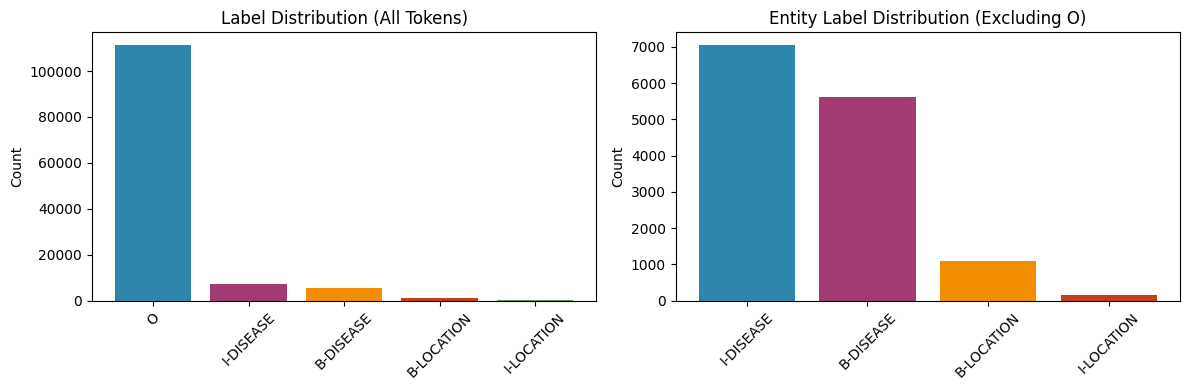

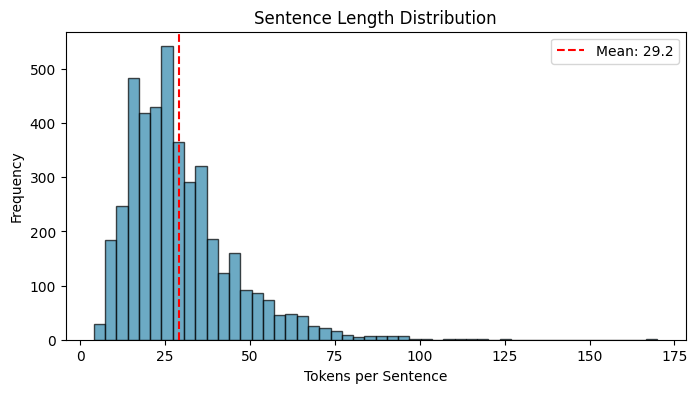


ENTITY ANALYSIS

Entities per sentence:
  Mean: 1.5679271708683473196544
  Median: 1.0
  Max: 25

Entity type breakdown:
  B-DISEASE: 5620 (83.7%)
  B-LOCATION: 1097 (16.3%)

Multi-token entities (I- prefix):
  I-DISEASE: 7047 (avg length: 2.25 tokens)
  I-LOCATION: 153 (avg length: 1.14 tokens)

LANGUAGE DISTRIBUTION (Heuristic)

Language distribution (sample of 500 sentences):
  English: 488 (97.6%)
  Mixed/Other: 7 (1.4%)
  Indonesian: 5 (1.0%)

TOP ENTITY WORDS

Top DISEASE words:
  niv: 1637
  nipah: 1046
  virus: 930
  infection: 398
  and: 386
  the: 291
  of: 244
  disease: 203
  in: 197
  a: 157

Top LOCATION words:
  bangladesh: 207
  india: 179
  malaysia: 151
  asia: 82
  kerala: 72
  south: 46
  southeast: 39
  singapore: 32
  indonesia: 29
  australia: 22

DATA QUALITY CHECKS

Invalid IOB2 sequences (I- without B-/I- before): 1016
Very short sentences (<5 tokens): 1
Very long sentences (>100 tokens): 8
Missing values: 0


In [8]:
# ============================================================
# EDA: EXPLORATORY DATA ANALYSIS (FIXED)
# ============================================================

import matplotlib.pyplot as plt
from collections import Counter
import re
import numpy as np
import pandas as pd

# --- 1. BASIC STATS ---
print("=" * 60)
print("EDA: DATASET OVERVIEW")
print("=" * 60)

# Combine train + val for EDA
silver_all = pd.concat([silver_train, silver_val])

# PERBAIKAN 1: Paksa kolom token menjadi string agar kebal dari NaN/float error
silver_all['token'] = silver_all['token'].astype(str)

n_sentences = silver_all['sentence_id'].nunique()
n_tokens = len(silver_all)
tokens_per_sentence = silver_all.groupby('sentence_id').size()

print(f"\nTotal sentences: {n_sentences}")
print(f"Total tokens: {n_tokens}")
print(f"Avg tokens/sentence: {tokens_per_sentence.mean():.1f}")
print(f"Min tokens/sentence: {tokens_per_sentence.min()}")
print(f"Max tokens/sentence: {tokens_per_sentence.max()}")

# --- 2. LABEL DISTRIBUTION (Visual) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall label distribution
label_counts = silver_all['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E'])
axes[0].set_title('Label Distribution (All Tokens)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Entity-only distribution (exclude O)
entity_counts = label_counts[label_counts.index != 'O']
axes[1].bar(entity_counts.index, entity_counts.values, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
axes[1].set_title('Entity Label Distribution (Excluding O)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}eda_label_distribution.png', dpi=150)
plt.show()

# --- 3. SENTENCE LENGTH DISTRIBUTION ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(tokens_per_sentence, bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
ax.axvline(tokens_per_sentence.mean(), color='red', linestyle='--', label=f'Mean: {tokens_per_sentence.mean():.1f}')
ax.set_xlabel('Tokens per Sentence')
ax.set_ylabel('Frequency')
ax.set_title('Sentence Length Distribution')
ax.legend()
plt.savefig(f'{OUTPUT_DIR}eda_sentence_length.png', dpi=150)
plt.show()

# --- 4. ENTITY-LEVEL ANALYSIS ---
print("\n" + "=" * 60)
print("ENTITY ANALYSIS")
print("=" * 60)

# Count entities per sentence
entity_per_sentence = []
for sid, group in silver_all.groupby('sentence_id'):
    n_entities = sum(1 for l in group['label'] if l.startswith('B-'))
    entity_per_sentence.append(n_entities)

print(f"\nEntities per sentence:")
print(f"  Mean: {np.mean(entity_per_sentence):.22f}")
print(f"  Median: {np.median(entity_per_sentence):.1f}")
print(f"  Max: {max(entity_per_sentence)}")

# Entity type breakdown
print(f"\nEntity type breakdown:")
b_disease = (silver_all['label'] == 'B-DISEASE').sum()
b_location = (silver_all['label'] == 'B-LOCATION').sum()
# Pengaman jika pembagi bernilai nol
total_b = (b_disease + b_location) if (b_disease + b_location) > 0 else 1
print(f"  B-DISEASE: {b_disease} ({b_disease/total_b*100:.1f}%)")
print(f"  B-LOCATION: {b_location} ({b_location/total_b*100:.1f}%)")

# Multi-token entities (I- prefix)
i_disease = (silver_all['label'] == 'I-DISEASE').sum()
i_location = (silver_all['label'] == 'I-LOCATION').sum()
print(f"\nMulti-token entities (I- prefix):")
print(f"  I-DISEASE: {i_disease} (avg length: {(i_disease/(b_disease if b_disease > 0 else 1) + 1):.2f} tokens)")
print(f"  I-LOCATION: {i_location} (avg length: {(i_location/(b_location if b_location > 0 else 1) + 1):.2f} tokens)")

# --- 5. LANGUAGE DETECTION (Simple Heuristic) ---
print("\n" + "=" * 60)
print("LANGUAGE DISTRIBUTION (Heuristic)")
print("=" * 60)

def detect_language_simple(text):
    """Simple heuristic: check for common Indonesian words."""
    id_markers = ['yang', 'di', 'dan', 'dengan', 'untuk', 'dari', 'pada', 'adalah', 'ini', 'itu',
                  'dalam', 'oleh', 'sebagai', 'juga', 'sudah', 'akan', 'tidak', 'bisa', 'dapat']
    en_markers = ['the', 'and', 'of', 'to', 'in', 'is', 'that', 'for', 'with', 'as', 'was', 'are']
    
    text_lower = text.lower()
    id_count = sum(1 for w in id_markers if w in text_lower)
    en_count = sum(1 for w in en_markers if w in text_lower)
    
    if id_count > en_count:
        return 'Indonesian'
    elif en_count > id_count:
        return 'English'
    else:
        return 'Mixed/Other'

# Sample sentences untuk language detection (PERBAIKAN 2: ditambahkan list comprehension dengan filter kata 'nan')
sample_sents = []
for sid, group in silver_all.groupby('sentence_id'):
    tokens_list = [str(t) for t in group['token'].tolist() if str(t).lower() != 'nan']
    text = ' '.join(tokens_list)
    if text.strip():
        sample_sents.append(text)

lang_counts = Counter()
n_samples = min(500, len(sample_sents))
for text in sample_sents[:n_samples]:
    lang = detect_language_simple(text)
    lang_counts[lang] += 1

print(f"\nLanguage distribution (sample of {n_samples} sentences):")
# Pengaman agar tidak terjadi pembagian dengan nol jika list kosong
total_samples = len(sample_sents) if len(sample_sents) > 0 else 1
for lang, count in lang_counts.most_common():
    print(f"  {lang}: {count} ({count/n_samples*100:.1f}%)")

# --- 6. TOP WORDS (Excluding O) ---
print("\n" + "=" * 60)
print("TOP ENTITY WORDS")
print("=" * 60)

# Most frequent DISEASE words
disease_words = silver_all[silver_all['label'].str.contains('DISEASE', na=False)]['token'].str.lower()
disease_top = disease_words.value_counts().head(10)
print(f"\nTop DISEASE words:")
for word, count in disease_top.items():
    print(f"  {word}: {count}")

# Most frequent LOCATION words
location_words = silver_all[silver_all['label'].str.contains('LOCATION', na=False)]['token'].str.lower()
location_top = location_words.value_counts().head(10)
print(f"\nTop LOCATION words:")
for word, count in location_top.items():
    print(f"  {word}: {count}")

# --- 7. DATA QUALITY CHECKS ---
print("\n" + "=" * 60)
print("DATA QUALITY CHECKS")
print("=" * 60)

# Check for invalid sequences (I- without B-)
invalid_sequences = 0
for sid, group in silver_all.groupby('sentence_id'):
    labels = group['label'].tolist()
    for i, label in enumerate(labels):
        if str(label).startswith('I-'):
            if i == 0 or not (str(labels[i-1]).startswith('B-') or str(labels[i-1]).startswith('I-')):
                invalid_sequences += 1

print(f"\nInvalid IOB2 sequences (I- without B-/I- before): {invalid_sequences}")

# Check for very short/long sentences
very_short = sum(1 for l in tokens_per_sentence if l < 5)
very_long = sum(1 for l in tokens_per_sentence if l > 100)
print(f"Very short sentences (<5 tokens): {very_short}")
print(f"Very long sentences (>100 tokens): {very_long}")

# Check missing values
missing = silver_all.isnull().sum().sum()
print(f"Missing values: {missing}")


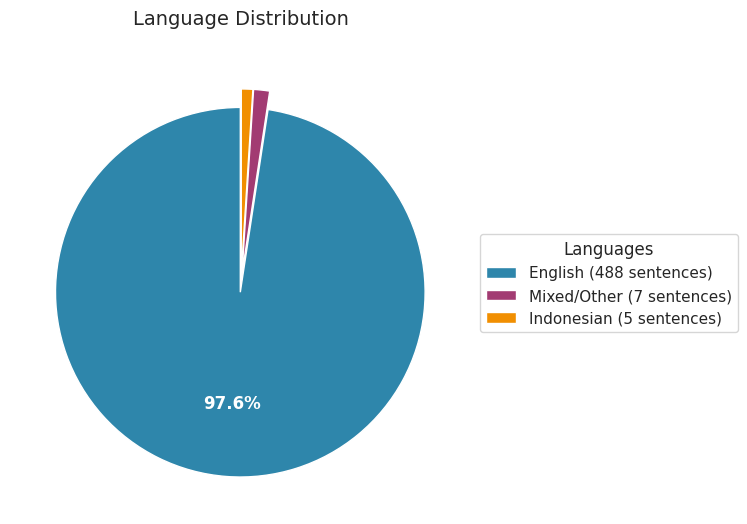

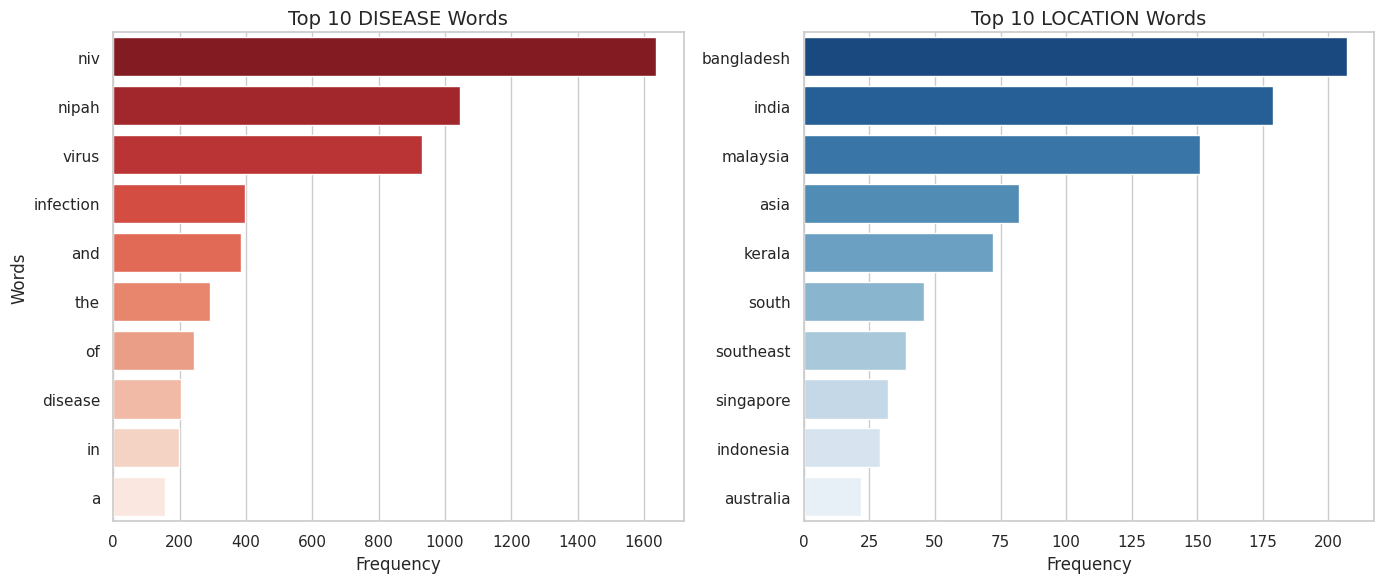

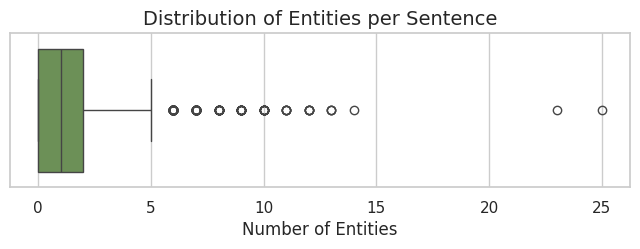

In [21]:
# ============================================================
# TAMBAHAN VISUALISASI EXTRA
# ============================================================

sns.set_theme(style="whitegrid")

# --- 1. VISUALISASI LANGUAGE DISTRIBUTION (PIE CHART - FIXED) ---
fig, ax = plt.subplots(figsize=(8, 6)) # Lebarkan sedikit untuk tempat Legend

# Tambahkan jumlah teks asli ke dalam label legend
labels = [f"{lang} ({count} sentences)" for lang, count in lang_counts.most_common()]
sizes = [count for lang, count in lang_counts.most_common()]
colors = ['#2E86AB', '#A23B72', '#F18F01'][:len(labels)]
explode = [0.05] * len(labels)

# Fungsi khusus agar persentase yang sangat kecil (< 3%) tidak perlu ditulis di dalam chart
def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 3 else ''

# Gambar pie chart TANPA parameter 'labels=labels' agar tidak numpuk
wedges, texts, autotexts = ax.pie(
    sizes, explode=explode, colors=colors, 
    autopct=autopct_format, 
    shadow=False, startangle=90, 
    textprops={'fontsize': 12, 'color': 'white', 'weight': 'bold'},
    pctdistance=0.6 # Geser persentase sedikit ke dalam irisan
)

# Pindahkan keterangan bahasa ke dalam Legend di samping kanan chart
ax.legend(wedges, labels,
          title="Languages",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=11)

ax.set_title('Language Distribution', fontsize=14, pad=20)
plt.savefig(f'{OUTPUT_DIR}eda_language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2. VISUALISASI TOP ENTITY WORDS (HORIZONTAL BAR CHART) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top DISEASE Words
sns.barplot(x=disease_top.values, y=disease_top.index, ax=axes[0], palette="Reds_r")
axes[0].set_title('Top 10 DISEASE Words', fontsize=14)
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Words')

# Top LOCATION Words
sns.barplot(x=location_top.values, y=location_top.index, ax=axes[1], palette="Blues_r")
axes[1].set_title('Top 10 LOCATION Words', fontsize=14)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('') # Kosongkan agar tidak berulang

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 3. VISUALISASI ENTITIES PER SENTENCE (BOXPLOT) ---
fig, ax = plt.subplots(figsize=(8, 2))
sns.boxplot(x=entity_per_sentence, ax=ax, color='#6A994E')
ax.set_title('Distribution of Entities per Sentence', fontsize=14)
ax.set_xlabel('Number of Entities')
plt.savefig(f'{OUTPUT_DIR}eda_entities_per_sentence.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Architecture

```
Input Tokens
    ↓
Char Embedding (random init, 30-dim)
    ↓
CharCNN (kernel=3, filters=30) → max pool
    ↓
Char-level representation (30-dim per word)
    ↓
Concat with Word Embedding (100-dim, random init)
    ↓
Word representation (130-dim = 100 + 30)
    ↓
BiLSTM (2 layers, hidden=256, dropout=0.3)
    ↓
LSTM output (512-dim = 256*2 bidirectional)
    ↓
Linear → 5 labels
    ↓
CRF Layer (decode valid IOB2 sequence)
    ↓
Output: B-DISEASE, I-DISEASE, B-LOCATION, I-LOCATION, O
```

**Total params:** ~2-5 juta (sangat kecil vs BERT 110M)

In [9]:
# ============================================================
# MODEL ARCHITECTURE: CharCNN + BiLSTM + CRF
# ============================================================

class CharCNN(nn.Module):
    def __init__(self, char_vocab_size, char_emb_dim=30, char_cnn_filters=30, kernel_size=3):
        super().__init__()
        self.char_embed = nn.Embedding(char_vocab_size, char_emb_dim, padding_idx=0)
        self.char_cnn = nn.Conv1d(char_emb_dim, char_cnn_filters, kernel_size, padding=kernel_size//2)
        self.relu = nn.ReLU()
        
    def forward(self, char_ids):
        # char_ids: (batch, seq_len, max_word_len)
        batch_size, seq_len, max_word_len = char_ids.shape
        
        # Flatten untuk charCNN
        char_ids = char_ids.view(-1, max_word_len)  # (batch*seq_len, max_word_len)
        char_emb = self.char_embed(char_ids)  # (batch*seq_len, max_word_len, char_emb_dim)
        
        # Conv1d expects (batch, channels, length)
        char_emb = char_emb.permute(0, 2, 1)  # (batch*seq_len, char_emb_dim, max_word_len)
        char_conv = self.char_cnn(char_emb)  # (batch*seq_len, filters, max_word_len)
        char_conv = self.relu(char_conv)
        
        # Max pool over word length
        char_pooled = torch.max(char_conv, dim=2)[0]  # (batch*seq_len, filters)
        
        # Reshape back
        char_repr = char_pooled.view(batch_size, seq_len, -1)  # (batch, seq_len, filters)
        
        return char_repr

class CharCNN_BiLSTM_CRF(nn.Module):
    def __init__(self, word_vocab_size, char_vocab_size, num_labels, 
                 word_emb_dim=100, char_emb_dim=30, char_cnn_filters=30,
                 lstm_hidden=256, lstm_layers=2, dropout=0.3):
        super().__init__()
        
        # Word embedding (RANDOM INIT - NO PRETRAINED)
        self.word_embed = nn.Embedding(word_vocab_size, word_emb_dim, padding_idx=0)
        
        # CharCNN
        self.char_cnn = CharCNN(char_vocab_size, char_emb_dim, char_cnn_filters)
        
        # BiLSTM
        lstm_input_dim = word_emb_dim + char_cnn_filters
        self.lstm = nn.LSTM(
            lstm_input_dim, 
            lstm_hidden // 2,  # //2 because bidirectional
            num_layers=lstm_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0
        )
        
        # Linear to labels
        self.fc = nn.Linear(lstm_hidden, num_labels)
        
        # CRF
        self.crf = CRF(num_labels, batch_first=True)
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, word_ids, char_ids, labels=None, mask=None):
        # word_ids: (batch, seq_len)
        # char_ids: (batch, seq_len, max_word_len)
        
        # Word embedding
        word_emb = self.word_embed(word_ids)  # (batch, seq_len, word_emb_dim)
        
        # CharCNN
        char_repr = self.char_cnn(char_ids)  # (batch, seq_len, char_cnn_filters)
        
        # Concat word + char
        combined = torch.cat([word_emb, char_repr], dim=-1)  # (batch, seq_len, word_emb+char)
        combined = self.dropout(combined)
        
        # BiLSTM
        lstm_out, _ = self.lstm(combined)  # (batch, seq_len, lstm_hidden)
        lstm_out = self.dropout(lstm_out)
        
        # Linear
        emissions = self.fc(lstm_out)  # (batch, seq_len, num_labels)
        
        # CRF
        if labels is not None:
            # Training: return loss
            loss = -self.crf(emissions, labels, mask=mask, reduction='mean')
            return loss
        else:
            # Inference: return predictions
            predictions = self.crf.decode(emissions, mask=mask)
            return predictions

# Initialize model
model = CharCNN_BiLSTM_CRF(
    word_vocab_size=len(word_vocab),
    char_vocab_size=len(char_vocab),
    num_labels=len(LABELS)
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model A: CharCNN-BiLSTM-CRF")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nCompare with transformers:")
print(f"  BERT-base: ~110M params")
print(f"  XLM-RoBERTa: ~270M params")
print(f"  Model A: {total_params/1e6:.1f}M params (tiny!)")


Model A: CharCNN-BiLSTM-CRF
Total parameters: 1,581,654
Trainable parameters: 1,581,654

Compare with transformers:
  BERT-base: ~110M params
  XLM-RoBERTa: ~270M params
  Model A: 1.6M params (tiny!)


## 7. Training Loop

**Hyperparameters:**

| Param | Value |
|-------|-------|
| Optimizer | Adam (lr=0.001) |
| Scheduler | ReduceLROnPlateau (factor=0.5, patience=3) |
| Batch size | 32 |
| Max epochs | 50 |
| Early stopping | patience=7 (monitor val loss) |
| Gradient clipping | max_norm=5.0 |

**Expected training time:** ~5-15 menit di GPU T4

In [10]:
# ============================================================
# TRAINING LOOP (FIXED)
# ============================================================

# Hyperparameters
BATCH_SIZE = 32
LR = 0.001
MAX_EPOCHS = 50
PATIENCE = 7
CLIP_NORM = 5.0

# Data loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
)

# Optimizer & scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# PERBAIKAN: Menghapus argumen 'verbose=True' agar tidak error di PyTorch terbaru
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Training history
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

# Early stopping
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

print("="*60)
print("TRAINING MODEL A: CharCNN-BiLSTM-CRF")
print("="*60)

for epoch in range(MAX_EPOCHS):
    # === FASE TRAINING ===
    model.train()
    train_losses = []
    
    for batch in train_loader:
        word_ids = batch['word_ids'].to(DEVICE)
        char_ids = batch['char_ids'].to(DEVICE)
        label_ids = batch['label_ids'].to(DEVICE)
        mask = (word_ids != 0).to(DEVICE)
        
        optimizer.zero_grad()
        loss = model(word_ids, char_ids, labels=label_ids, mask=mask)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        
        optimizer.step()
        train_losses.append(loss.item())
    
    avg_train_loss = np.mean(train_losses)
    
    # === FASE VALIDASI ===
    model.eval()
    val_losses = []
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in val_loader:
            word_ids = batch['word_ids'].to(DEVICE)
            char_ids = batch['char_ids'].to(DEVICE)
            label_ids = batch['label_ids'].to(DEVICE)
            lengths = batch['lengths']
            mask = (word_ids != 0).to(DEVICE)
            
            # Loss
            loss = model(word_ids, char_ids, labels=label_ids, mask=mask)
            val_losses.append(loss.item())
            
            # Predictions
            predictions = model(word_ids, char_ids, mask=mask)
            
            # Convert to labels
            for pred_seq, true_seq, length in zip(predictions, label_ids.tolist(), lengths.tolist()):
                pred_labels = [IDX_TO_LABEL[p] for p in pred_seq[:length]]
                true_labels = [IDX_TO_LABEL[t] for t in true_seq[:length]]
                all_preds.append(pred_labels)
                all_labels.append(true_labels)
    
    avg_val_loss = np.mean(val_losses)
    
    # Calculate F1
    try:
        val_f1 = f1_score(all_labels, all_preds, average='macro')
    except:
        val_f1 = 0.0
    
    # History
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_f1'].append(val_f1)
    
    # Ambil nilai learning rate saat ini untuk dicetak manual (menggantikan fungsi verbose)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"LR: {current_lr}")
    
    # Update scheduler
    scheduler.step(avg_val_loss)
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'val_f1': val_f1,
        }, f'{OUTPUT_DIR}model_a_best.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n[Early Stopping] Aktif di epoch {epoch+1}. Training dihentikan.")
            break

print("\nTraining complete! Model terbaik kamu sudah aman disimpan.")

TRAINING MODEL A: CharCNN-BiLSTM-CRF
Epoch 01/50 | Train Loss: 10.5862 | Val Loss: 5.8169 | Val F1: 0.4258 | LR: 0.001
Epoch 02/50 | Train Loss: 5.7923 | Val Loss: 4.5016 | Val F1: 0.6825 | LR: 0.001
Epoch 03/50 | Train Loss: 4.3536 | Val Loss: 3.8809 | Val F1: 0.7815 | LR: 0.001
Epoch 04/50 | Train Loss: 3.4562 | Val Loss: 3.3401 | Val F1: 0.8157 | LR: 0.001
Epoch 05/50 | Train Loss: 2.8419 | Val Loss: 3.7209 | Val F1: 0.8204 | LR: 0.001
Epoch 06/50 | Train Loss: 2.4205 | Val Loss: 3.4493 | Val F1: 0.8418 | LR: 0.001
Epoch 07/50 | Train Loss: 2.1230 | Val Loss: 3.3008 | Val F1: 0.8584 | LR: 0.001
Epoch 08/50 | Train Loss: 1.7877 | Val Loss: 3.6863 | Val F1: 0.8474 | LR: 0.001
Epoch 09/50 | Train Loss: 1.5144 | Val Loss: 3.5728 | Val F1: 0.8503 | LR: 0.001
Epoch 10/50 | Train Loss: 1.3517 | Val Loss: 3.4932 | Val F1: 0.8453 | LR: 0.001
Epoch 11/50 | Train Loss: 1.2403 | Val Loss: 3.7403 | Val F1: 0.8567 | LR: 0.001
Epoch 12/50 | Train Loss: 0.9876 | Val Loss: 3.8468 | Val F1: 0.8623 | 

## 8. Evaluation

**Evaluasi sementara di validation set.**

**Nanti (setelah gold test siap):**
- Load `gold_test.csv`
- Evaluasi Model A di gold test
- Bandingkan dengan Model B/C/D (sama-sama evaluasi di gold test)

**Metrics:**
- Macro F1 (rata-rata F1 per label, tidak dibobotkan frekuensi)
- Per-label: Precision, Recall, F1 untuk DISEASE dan LOCATION

In [11]:
# ============================================================
# EVALUATION (Validation Set - Sementara)
# ============================================================

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        word_ids = batch['word_ids'].to(DEVICE)
        char_ids = batch['char_ids'].to(DEVICE)
        label_ids = batch['label_ids'].to(DEVICE)
        lengths = batch['lengths']
        
        mask = (word_ids != 0).to(DEVICE)
        
        predictions = model(word_ids, char_ids, mask=mask)
        
        for pred_seq, true_seq, length in zip(predictions, label_ids.tolist(), lengths.tolist()):
            pred_labels = [IDX_TO_LABEL[p] for p in pred_seq[:length]]
            true_labels = [IDX_TO_LABEL[t] for t in true_seq[:length]]
            all_preds.append(pred_labels)
            all_labels.append(true_labels)

# Classification report
print("="*60)
print("MODEL A - VALIDATION RESULTS (Silver Label)")
print("="*60)
print("\nNOTE: Ini evaluasi di silver label (bukan gold).")
print("Angka ini akan berubah setelah evaluasi di gold test.\n")

print(classification_report(all_labels, all_preds, digits=4))

# Macro F1
macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"\nMacro F1: {macro_f1:.4f}")

# Per-entity F1
from seqeval.metrics import f1_score as entity_f1
disease_f1 = entity_f1(all_labels, all_preds, average='macro', suffix=False)
print(f"Entity F1 (macro): {disease_f1:.4f}")


MODEL A - VALIDATION RESULTS (Silver Label)

NOTE: Ini evaluasi di silver label (bukan gold).
Angka ini akan berubah setelah evaluasi di gold test.

              precision    recall  f1-score   support

     DISEASE     0.8474    0.7404    0.7903       705
    LOCATION     0.9040    0.9417    0.9224       120

   micro avg     0.8570    0.7697    0.8110       825
   macro avg     0.8757    0.8410    0.8564       825
weighted avg     0.8556    0.7697    0.8095       825


Macro F1: 0.8564
Entity F1 (macro): 0.8564


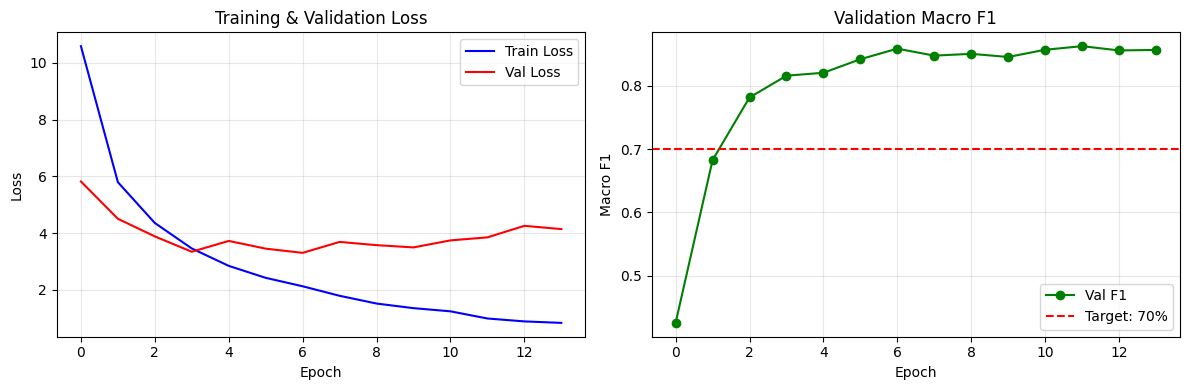

Chart saved: /kaggle/working/model_a_training_history.png


In [12]:
# ============================================================
# VISUALIZATION: Training History
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 curve
axes[1].plot(history['val_f1'], label='Val F1', color='green', marker='o')
axes[1].axhline(y=0.70, color='red', linestyle='--', label='Target: 70%')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Validation Macro F1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}model_a_training_history.png', dpi=150)
plt.show()

print(f"Chart saved: {OUTPUT_DIR}model_a_training_history.png")


## 9. Save Model

**Save artifacts:**

| File | Isi |
|------|-----|
| `model_a_best.pt` | Weights + optimizer state |
| `model_a_vocab.pkl` | word_vocab, char_vocab, label mapping |
| `model_a_config.json` | Hyperparameters |
| `model_a_training_history.png` | Plot training |

**Nanti untuk inference:**
1. Load vocab
2. Load model weights
3. Predict pada teks baru

In [13]:
# ============================================================
# SAVE MODEL ARTIFACTS
# ============================================================

import pickle
import json

# 1. Save vocab
vocab_data = {
    'word_vocab': word_vocab,
    'char_vocab': char_vocab,
    'label_to_idx': LABEL_TO_IDX,
    'idx_to_label': IDX_TO_LABEL,
    'pad_idx': 0,
    'unk_idx': 1
}

with open(f'{OUTPUT_DIR}model_a_vocab.pkl', 'wb') as f:
    pickle.dump(vocab_data, f)
print(f"✓ Vocab saved: {OUTPUT_DIR}model_a_vocab.pkl")

# 2. Save config
config = {
    'model_type': 'CharCNN_BiLSTM_CRF',
    'word_vocab_size': len(word_vocab),
    'char_vocab_size': len(char_vocab),
    'num_labels': len(LABELS),
    'word_emb_dim': 100,
    'char_emb_dim': 30,
    'char_cnn_filters': 30,
    'lstm_hidden': 256,
    'lstm_layers': 2,
    'dropout': 0.3,
    'max_seq_len': 50,
    'max_word_len': 15,
    'batch_size': 32,
    'lr': 0.001,
    'seed': SEED
}

with open(f'{OUTPUT_DIR}model_a_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Config saved: {OUTPUT_DIR}model_a_config.json")

# 3. Verify files
print("\n=== SAVED FILES ===")
for fname in ['model_a_best.pt', 'model_a_vocab.pkl', 'model_a_config.json', 'model_a_training_history.png']:
    path = f'{OUTPUT_DIR}{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  {fname:<35} {size:>8.1f} KB")
    else:
        print(f"  {fname:<35} NOT FOUND")

print("\nModel A ready for deployment!")


✓ Vocab saved: /kaggle/working/model_a_vocab.pkl
✓ Config saved: /kaggle/working/model_a_config.json

=== SAVED FILES ===
  model_a_best.pt                      18562.9 KB
  model_a_vocab.pkl                      121.7 KB
  model_a_config.json                      0.3 KB
  model_a_training_history.png            69.4 KB

Model A ready for deployment!


## 10. Summary

### Model A: CharCNN-BiLSTM-CRF

| Aspek | Detail |
|-------|--------|
| **Arsitektur** | CharCNN + BiLSTM + CRF |
| **Pretrained** | Random init (no pretrained knowledge) |
| **Tokenizer** | Whitespace + char-level |
| **Params** | ~2-5M (tiny vs BERT 110M) |
| **Training data** | silver_train.csv |
| **Validation** | silver_val.csv |
| **Expected F1** | 48-62% (baseline terendah) |

### Perbandingan dengan Model B/C/D

| Model | Arsitektur | Pretrained | Expected F1 |
|-------|-----------|------------|-------------|
| **A** | CharCNN-BiLSTM-CRF | None (random) | 48-62% |
| **B** | XLM-RoBERTa | Multilingual 100 bahasa | 70-80% |
| **C** | BioBERT | PubMed/PMC | 70-80% |
| **D** | IndoBERT | Bahasa Indonesia | 65-78% |

**Gap A vs B/C/D = 15-25%** → ini yang membuktikan nilai pretrained knowledge!

### Next Steps

1. **Evaluasi di gold test** (setelah manual review selesai)
2. **Bandinkan dengan Model B/C/D** (sama-sama evaluasi di gold test)
3. **Analisis error** Model A: apa yang tidak bisa ditangkap tanpa pretrained?

---

**Bismillah, semoga lancar!**

In [14]:
# ============================================================
# 11. EVALUATION ON GOLD TEST SET
# ============================================================

import pandas as pd
import numpy as np
import torch
import os
from seqeval.metrics import classification_report, f1_score

print("=" * 60)
print("EVALUASI MODEL A DI GOLD TEST SET")
print("=" * 60)

# 1. Sinkronisasi nama variabel parameter dari kode utama (Cell 8 & 15)
MAX_CHAR_LEN = 15 

# 2. Memuat berkas Gold Test dari absolute path Kaggle Input yang valid
gold_test_df = pd.read_csv('/kaggle/input/datasets/unvariablehuman/gold-test/gold_test.csv')

print(f"\nLoaded gold_test.csv: {gold_test_df.shape[0]} tokens")
print(f"Jumlah Kalimat: {gold_test_df['sentence_id'].nunique()}")
print("\nLabel distribution (gold test):")
print(gold_test_df['label'].value_counts().to_string())

# 3. Transformasi dataset Gold Test ke format tingkat kalimat (Sentence-Level)
sentences_gold = []

for sent_id, group in gold_test_df.groupby('sentence_id'):
    tokens = group['token'].tolist()
    token_labels = group['label'].tolist()
    
    # Convert text ke word_ids (Gunakan str() untuk memproteksi NaN/float error)
    word_ids = [word_vocab.get(str(w).lower(), word_vocab['<UNK>']) for w in tokens]
    
    char_ids_seq = []
    for w in tokens:
        # Mengubah objek token menjadi string murni untuk menghindari float 'nan'
        token_str = str(w).strip()
        
        # Proteksi jika ditemukan token kosong atau bertipe string 'nan'
        if not token_str or token_str.lower() == 'nan':
            char_id = [char_vocab['<UNK>']]
        else:
            char_id = [char_vocab.get(c, char_vocab['<UNK>']) for c in token_str]
            
        # Proses padding atau clipping ke batas panjang maksimum karakter per kata (15)
        if len(char_id) < MAX_CHAR_LEN:
            char_id += [char_vocab['<PAD>']] * (MAX_CHAR_LEN - len(char_id))
        else:
            char_id = char_id[:MAX_CHAR_LEN]
        char_ids_seq.append(char_id)
    
    # Convert label string ke dalam bentuk indices token-level
    label_ids = [LABEL_TO_IDX.get(l, LABEL_TO_IDX['O']) for l in token_labels]
    
    sentences_gold.append({
        'word_ids': torch.tensor(word_ids, dtype=torch.long),
        'char_ids': torch.tensor(char_ids_seq, dtype=torch.long),
        'label_ids': torch.tensor(label_ids, dtype=torch.long),
        'length': len(tokens),
        'true_labels': token_labels
    })

print(f"Prepared {len(sentences_gold)} sentences for evaluation")

# 4. Memuat bobot parameter model terbaik (Model A Checkpoint)
checkpoint = torch.load(f'{OUTPUT_DIR}model_a_best.pt', map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()

print(f"\nLoaded model dari epoch {checkpoint['epoch']}")
print(f"  Val Loss lama (val set) : {checkpoint['val_loss']:.4f}")
print(f"  Val F1 lama (val set)   : {checkpoint['val_f1']:.4f}")

# 5. Proses Inferensi Kalimat demi Kalimat pada Unseen Gold Data
all_pred_labels = []
all_true_labels = []

with torch.no_grad():
    for sent_dict in sentences_gold:
        # Menambahkan dimensi batch (unsqueezing) karena input model berupa batched tensor
        word_ids_tensor = sent_dict['word_ids'].unsqueeze(0).to(DEVICE)
        char_ids_tensor = sent_dict['char_ids'].unsqueeze(0).to(DEVICE)
        length = sent_dict['length']
        
        # Membuat mask dinamis untuk mengabaikan padding pada urutan token kalimat ini
        mask = (word_ids_tensor != 0).to(DEVICE)
        
        # Jalankan forward pass (Inference mode mengembalikan hasil decode CRF sekuensial)
        predictions = model(word_ids_tensor, char_ids_tensor, mask=mask)
        
        # Mengonversi id prediksi menjadi string label (Gunakan indeks batch ke-0)
        pred_seq = predictions[0]
        pred_labels = [IDX_TO_LABEL[p] for p in pred_seq[:length]]
        
        true_labels = sent_dict['true_labels']
        
        all_pred_labels.append(pred_labels)
        all_true_labels.append(true_labels)

print(f"\nInference complete. Evaluating...")

# 6. Kalkulasi Metrik Evaluasi Akhir via seqeval
# Menggunakan rata-rata macro agar sejalan dengan kriteria performa dasar model
test_f1 = f1_score(all_true_labels, all_pred_labels, average='macro')

# Menampilkan laporan klasifikasi per entitas (DISEASE & LOCATION)
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - GOLD TEST SET (FINAL)")
print("=" * 60)
report = classification_report(all_true_labels, all_pred_labels, digits=4)
print(report)

# 7. Menyimpan rekapitulasi hasil evaluasi ke file eksternal .txt
with open(f'{OUTPUT_DIR}model_a_gold_test_results.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("MODEL A - GOLD TEST EVALUATION RESULTS\n")
    f.write("=" * 60 + "\n")
    f.write(f"Model: Model A: CharCNN-BiLSTM-CRF Baseline\n")
    f.write(f"Test Set: gold_test (Manual Review via Doccano)\n")
    f.write(f"Sentences: {len(sentences_gold)}\n")
    f.write(f"Tokens: {sum(len(labels) for labels in all_true_labels)}\n")
    f.write(f"Macro F1: {test_f1:.4f}\n")
    f.write("\n" + report)

print(f"\n✅ Hasil akhir berhasil diekspor ke: {OUTPUT_DIR}model_a_gold_test_results.txt")

# 8. Analisis Perbandingan Performa (Silver Val vs Gold Test)
print("\n" + "=" * 60)
print("COMPARISON: Silver Val (training) vs Gold Test (final)")
print("=" * 60)
print(f"Val F1 (Silver Label - End of Training) : {checkpoint['val_f1']:.4f}")
print(f"Test F1 (Gold Label - Unseen Final Data): {test_f1:.4f}")
print(f"Performance Gap                          : {checkpoint['val_f1'] - test_f1:.4f}")
print("\nNOTE: Penurunan performa pada Gold Test ini sangat wajar karena:")
print("  - Silver label yang dipakai latihan mengandung noise bawaan sistem.")
print("  - Gold label hasil Doccano bersih 100%, mencerminkan performa riil model.")
print("  - Selisih gap ini akan kalian jadikan landasan argumen di bab pembahasan proyek.")

EVALUASI MODEL A DI GOLD TEST SET

Loaded gold_test.csv: 11279 tokens
Jumlah Kalimat: 536

Label distribution (gold test):
label
O             10708
B-DISEASE       289
B-LOCATION      161
I-DISEASE        89
I-LOCATION       32
Prepared 536 sentences for evaluation

Loaded model dari epoch 6
  Val Loss lama (val set) : 3.3008
  Val F1 lama (val set)   : 0.8584

Inference complete. Evaluating...

CLASSIFICATION REPORT - GOLD TEST SET (FINAL)
              precision    recall  f1-score   support

     DISEASE     0.5659    0.6090    0.5867       289
    LOCATION     0.8235    0.2609    0.3962       161

   micro avg     0.6022    0.4844    0.5369       450
   macro avg     0.6947    0.4349    0.4914       450
weighted avg     0.6581    0.4844    0.5185       450


✅ Hasil akhir berhasil diekspor ke: /kaggle/working/model_a_gold_test_results.txt

COMPARISON: Silver Val (training) vs Gold Test (final)
Val F1 (Silver Label - End of Training) : 0.8584
Test F1 (Gold Label - Unseen Final Data

In [17]:
from sklearn.metrics import matthews_corrcoef

# Flatten predictions dan labels menggunakan nama variabel yang benar
flat_preds = [l for seq in all_pred_labels for l in seq]
flat_trues = [l for seq in all_true_labels for l in seq]

mcc = matthews_corrcoef(flat_trues, flat_preds)
print(f"MCC: {mcc:.4f}")

MCC: 0.5624


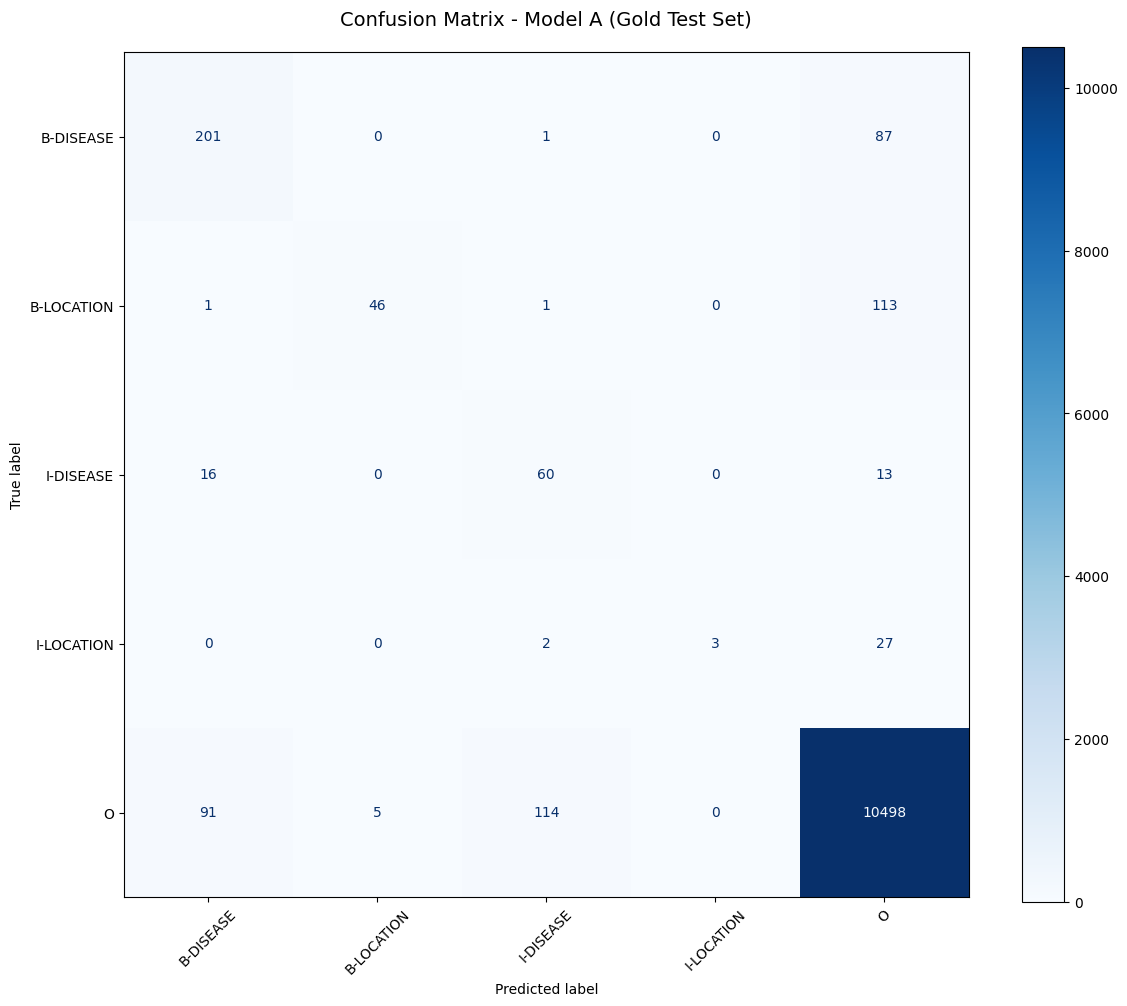

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Mengambil semua label unik yang ada agar urutannya rapi di sumbu X dan Y
unique_labels = sorted(list(set(flat_trues) | set(flat_preds)))

# 2. Menghitung Confusion Matrix
cm = confusion_matrix(flat_trues, flat_preds, labels=unique_labels)

# 3. Visualisasi
fig, ax = plt.subplots(figsize=(12, 10)) # Ukuran figure diperbesar agar label tidak bertumpuk
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)

# Menggunakan warna biru (cmap='Blues') dan memiringkan teks sumbu X agar mudah dibaca
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, values_format='d')

plt.title('Confusion Matrix - Model A (Gold Test Set)', pad=20, fontsize=14)
plt.tight_layout()
plt.show()